[ 8  8  8  9  9  9  9  9  9 10]


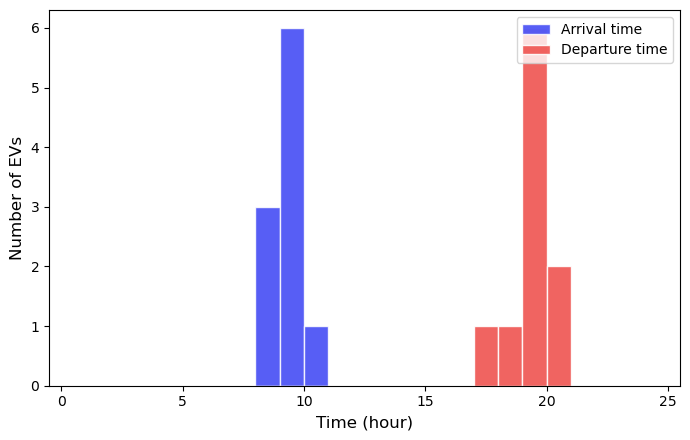

=== 實際氣象資料計算結果 ===
最高氣溫: 30.2 °C
最高日照強度: 0.847 kW/m^2
單日最高發電功率: 182.52 kW
單日總太陽能發電量: 1267.75 kWh

=== 實際大樓用電資料 (bh) ===
單日最高負載: 157.90 kW
單日總用電量: 2894.36 kWh



In [18]:
#參數決定
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 參數（可動）

T = range(24)
building_area = 1081.65

totalcost_arr= []
gridimport_arr = []

   
PV_install_rate = 1  # 0~1

ev_count = 10

I = range(ev_count)

ev_capacity_single = 67.5  # kWh per EV
ev_ch_max_single = 7      # kW per EV
ev_dis_max_single = 7    # kW per EV

# 站點總功率限制
ev_station_ch_limit = 110  # kW total charging limit
ev_station_dis_limit = 35  # kW total discharging limit

bat_count = 10
bat_cap = 13.5 * bat_count
bat_ch_max = 5 * bat_count
bat_dis_max = 5 * bat_count

bat_init_pct = 0.2
bat_min_pct = 0.2
bat_max_pct = 0.9

eta_ch = 0.95
eta_dis = 0.95

# 充放電成本
ev_deg_cost = 0
bat_deg_cost = 0

# 修改後的每台車來往時間 (符合論文的卜瓦松與指數分配反函數法)
np.random.seed(42)

lambda_arr = ev_count / 2.0  
lambda_dep = ev_count / 4.0  

u_arr = np.random.uniform(0, 1, ev_count)
inter_arrival_times = -np.log(1 - u_arr) / lambda_arr

arrival_times = 7.5 + np.cumsum(inter_arrival_times)

arrival_times = np.round(arrival_times).astype(int)
arrival_times = np.clip(arrival_times, 0, 23)

u_dep = np.random.uniform(0, 1, ev_count)
inter_departure_times = -np.log(1 - u_dep) / lambda_dep

departure_times = 16.5 + np.cumsum(inter_departure_times)

departure_times = np.round(departure_times).astype(int)
departure_times = np.clip(departure_times, 0, 23)

departure_times = np.maximum(departure_times, arrival_times + 1)

soc_init_pcts = np.random.uniform(0.1, 0.4, size=ev_count)
soc_target_pcts = np.full(ev_count, 0.9)

plt.figure(figsize=(7, 4.5))

bins = np.arange(0, 26, 1)
print(arrival_times)
plt.hist(arrival_times, bins=bins, color='#3A42F4', alpha=0.85, edgecolor='white', label='Arrival time')
plt.hist(departure_times, bins=bins, color='#EF5350', alpha=0.9, edgecolor='white', label='Departure time')

plt.xlabel('Time (hour)', fontsize=12)
plt.ylabel('Number of EVs', fontsize=12)

plt.xlim(-0.5, 25.5)
plt.xticks(np.arange(0, 26, 5))

plt.legend(loc='upper right')

plt.tight_layout()
plt.show()
# 環境

#PV,參考文獻：QUANTITATIVE PERFORMANCE ASSESSMENT AND OPTIMAL DESIGN OF MICROGRID SYSTEMS CONSIDERING SUPPLYDEMAND UNCERTAINTIES

df_weather = pd.read_csv("466920-2026-05-12.csv", header=0)
df_weather = df_weather.drop(0).reset_index(drop=True)

# 氣溫 (T_amb) 與 日照量 (GloblRad)
t_amb_data = pd.to_numeric(df_weather['氣溫(℃)'], errors='coerce').ffill().values
rad_mj_data = pd.to_numeric(df_weather['全天空日射量(MJ/㎡)'], errors='coerce').fillna(0).values

# 單位轉換：1 MJ/m^2/hour = 1/3.6 kW/m^2
rad_kw_data = rad_mj_data / 3.6

# PV 面板物理參數設定
T_ref = 25.0              
K_pv = -3.7e-3            
A_pv = building_area * PV_install_rate            
eta_pv = 0.22            # https://netzero.sinica.edu.tw/cases_detail/12

rh = np.zeros(24)
for t in range(24):
    if rad_kw_data[t] > 0:
        # 面板升溫公式 (Eq. 3.2)，帶入的 Rad 轉換為 W/m^2
        Rad_W = rad_kw_data[t] * 1000
        T_pv = t_amb_data[t] + 0.0256 * Rad_W
        
        # 實際發電功率公式 (Eq. 3.1)，輸出為 kW
        p_pv_t = rad_kw_data[t] * A_pv * (1 + K_pv * (T_pv - T_ref)) * eta_pv
        rh[t] = max(0, p_pv_t)
    else:
        rh[t] = 0

print("=== 實際氣象資料計算結果 ===")
print(f"最高氣溫: {np.max(t_amb_data):.1f} °C")
print(f"最高日照強度: {np.max(rad_kw_data):.3f} kW/m^2")
print(f"單日最高發電功率: {np.max(rh):.2f} kW")
print(f"單日總太陽能發電量: {np.sum(rh):.2f} kWh")
print("==========================\n")

# 電表
df_meter = pd.read_csv("0512電表.csv", header=1)
bh = pd.to_numeric(df_meter.iloc[:, 1], errors='coerce').ffill().values

print("=== 實際大樓用電資料 (bh) ===")
print(f"單日最高負載: {np.max(bh):.2f} kW")
print(f"單日總用電量: {np.sum(bh):.2f} kWh")
print("=============================\n")
off = 1
price_gap = 1
cheapest_price = 2.23
#price = np.array([cheapest_price * off]*9 + [(cheapest_price + price_gap)  * off]*7 + [(cheapest_price + 2 * price_gap) * off]*6 + [(cheapest_price + price_gap) * off]*2)
price = np.array([2.23 * off]*9 + [5.02 * off]*7 + [8.12 * off]*6 + [5.02 * off]*2)

Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 25.3.0 25D2128)

CPU model: Apple M3
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 1398 rows, 1259 columns and 4033 nonzeros (Min)
Model fingerprint: 0xf2a50b14
Model has 24 linear objective coefficients
Variable types: 995 continuous, 264 integer (264 binary)
Coefficient statistics:
  Matrix range     [7e-03, 5e+01]
  Objective range  [2e+00, 8e+00]
  Bounds range     [2e-01, 5e+01]
  RHS range        [1e-01, 2e+02]

Presolve removed 1055 rows and 794 columns
Presolve time: 0.00s
Presolved: 343 rows, 465 columns, 1175 nonzeros
Variable types: 341 continuous, 124 integer (124 binary)
Found heuristic solution: objective 11850.766080
Found heuristic solution: objective 11161.487258

Root relaxation: objective 1.089283e+04, 224 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      

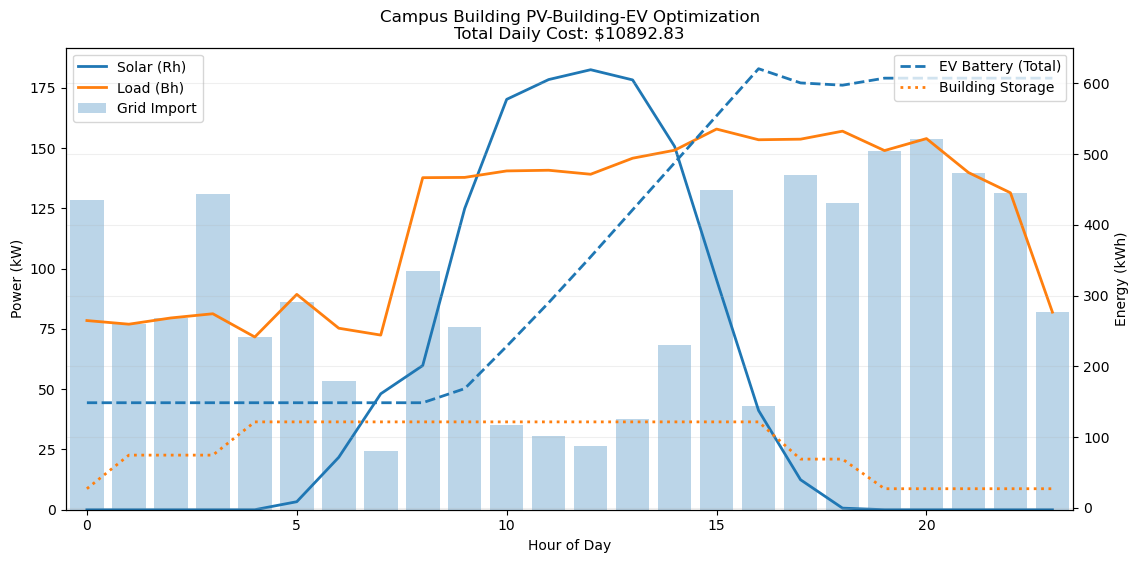

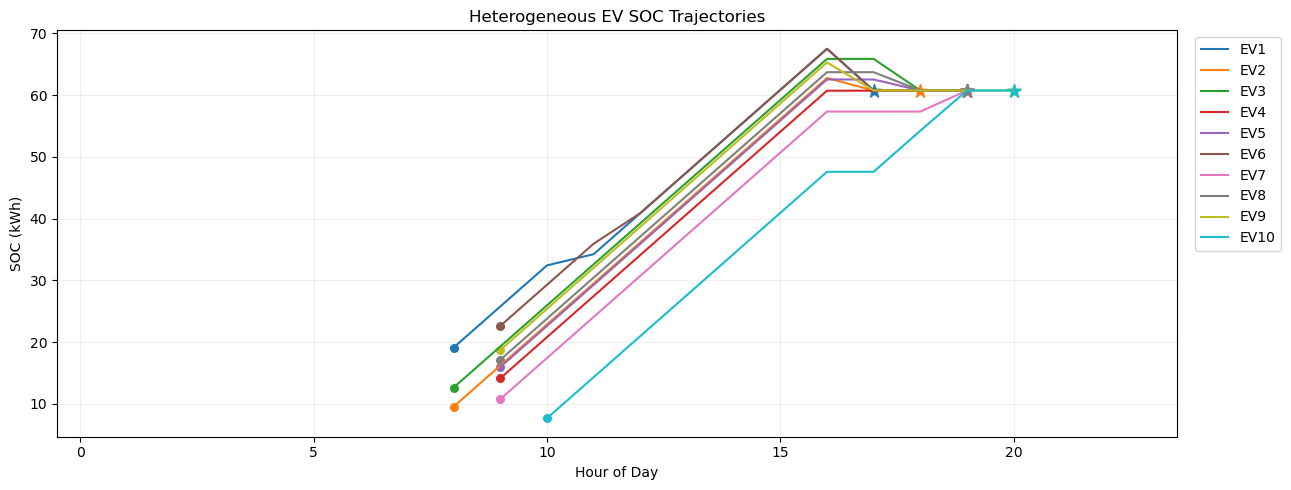

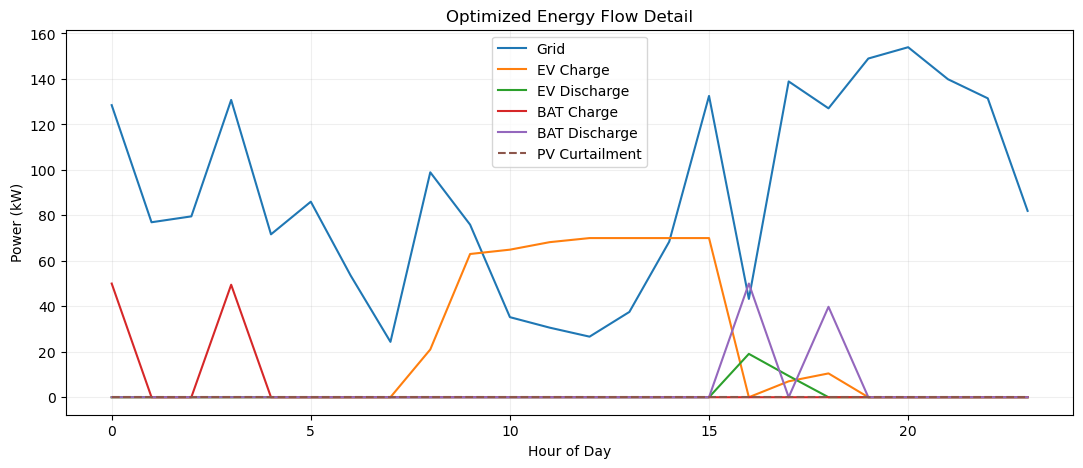

In [20]:
# gurobi最佳化
# ============================================================
# 2. Model
# ============================================================

m = gp.Model("PV_Building_EV_Gurobi_PerEV_NoDemandCharge")

# ============================================================
# 3. Variables
# ============================================================

# Grid
grid = m.addVars(T, lb=0, name="grid")

# PV allocation
pv_to_load = m.addVars(T, lb=0, name="pv_to_load")
pv_to_ev = m.addVars(T, lb=0, name="pv_to_ev")
pv_to_bat = m.addVars(T, lb=0, name="pv_to_bat")
pv_curt = m.addVars(T, lb=0, name="pv_curt")

# Grid allocation
grid_to_load = m.addVars(T, lb=0, name="grid_to_load")
grid_to_ev = m.addVars(T, lb=0, name="grid_to_ev")
grid_to_bat = m.addVars(T, lb=0, name="grid_to_bat")

# EV per vehicle
ev_ch = m.addVars(I, T, lb=0, ub=ev_ch_max_single, name="ev_ch")
ev_dis = m.addVars(I, T, lb=0, ub=ev_dis_max_single, name="ev_dis")
soc_ev = m.addVars(I, range(25), lb=0.0, ub=1.0, name="soc_ev")
ev_mode = m.addVars(I, T, vtype=GRB.BINARY, name="ev_mode")

# Battery
bat_ch = m.addVars(T, lb=0, ub=bat_ch_max, name="bat_ch")
bat_dis = m.addVars(T, lb=0, ub=bat_dis_max, name="bat_dis")
soc_bat = m.addVars(range(25), lb=bat_min_pct, ub=bat_max_pct, name="soc_bat")
bat_mode = m.addVars(T, vtype=GRB.BINARY, name="bat_mode")

# ============================================================
# 4. Constraints
# ============================================================

# Initial SOC
for i in I:
    m.addConstr(soc_ev[i, 0] == soc_init_pcts[i], name=f"ev_init_{i}")

m.addConstr(soc_bat[0] == bat_init_pct, name="bat_init")

for t in T:
    # ----------------------------
    # PV balance
    # ----------------------------
    m.addConstr(
        pv_to_load[t] + pv_to_ev[t] + pv_to_bat[t] + pv_curt[t] == rh[t],
        name=f"pv_balance_{t}"
    )

    # ----------------------------
    # Building load balance
    # ----------------------------
    m.addConstr(
        pv_to_load[t]
        + grid_to_load[t]
        + gp.quicksum(ev_dis[i, t] for i in I)
        + bat_dis[t]
        == bh[t],
        name=f"load_balance_{t}"
    )

    # ----------------------------
    # EV charging source balance
    # ----------------------------
    m.addConstr(
        gp.quicksum(ev_ch[i, t] for i in I) == pv_to_ev[t] + grid_to_ev[t],
        name=f"ev_charge_source_{t}"
    )

    # ----------------------------
    # Battery charging source balance
    # ----------------------------
    m.addConstr(
        bat_ch[t] == pv_to_bat[t] + grid_to_bat[t],
        name=f"bat_charge_source_{t}"
    )

    # ----------------------------
    # Grid total
    # ----------------------------
    m.addConstr(
        grid[t] == grid_to_load[t] + grid_to_ev[t] + grid_to_bat[t],
        name=f"grid_total_{t}"
    )

    # ----------------------------
    # Station total power limit
    # ----------------------------
    m.addConstr(
        gp.quicksum(ev_ch[i, t] for i in I) <= ev_station_ch_limit,
        name=f"station_ch_limit_{t}"
    )
    m.addConstr(
        gp.quicksum(ev_dis[i, t] for i in I) <= ev_station_dis_limit,
        name=f"station_dis_limit_{t}"
    )

    # ----------------------------
    # Battery SOC update & mode limits
    # ----------------------------
    m.addConstr(
        soc_bat[t+1] == soc_bat[t] + bat_ch[t] * eta_ch / bat_cap - bat_dis[t] / (eta_dis * bat_cap),
        name=f"bat_soc_update_{t}"
    )
    m.addConstr(bat_ch[t] <= bat_ch_max * bat_mode[t], name=f"bat_ch_mode_{t}")
    m.addConstr(bat_dis[t] <= bat_dis_max * (1 - bat_mode[t]), name=f"bat_dis_mode_{t}")

    # ----------------------------
    # EV constraints
    # ----------------------------
    for i in I:
        m.addConstr(
            soc_ev[i, t+1] == soc_ev[i, t] + ev_ch[i, t] * eta_ch / ev_capacity_single - ev_dis[i, t] / (eta_dis * ev_capacity_single),
            name=f"ev_soc_update_{i}_{t}"
        )

        if t < arrival_times[i] or t >= departure_times[i]:
            m.addConstr(ev_ch[i, t] == 0, name=f"ev_ch_unavailable_{i}_{t}")
            m.addConstr(ev_dis[i, t] == 0, name=f"ev_dis_unavailable_{i}_{t}")
            m.addConstr(soc_ev[i, t+1] == soc_ev[i, t], name=f"ev_soc_hold_{i}_{t}")

        m.addConstr(ev_ch[i, t] <= ev_ch_max_single * ev_mode[i, t], name=f"ev_ch_mode_{i}_{t}")
        m.addConstr(ev_dis[i, t] <= ev_dis_max_single * (1 - ev_mode[i, t]), name=f"ev_dis_mode_{i}_{t}")

for i in I:
    m.addConstr(
        soc_ev[i, departure_times[i]] >= soc_target_pcts[i],
        name=f"ev_departure_target_{i}"
    )

# ============================================================
# 5. Objective
# ============================================================

m.setObjective(
    gp.quicksum(grid[t] * price[t] for t in T)          
    + gp.quicksum((ev_ch[i, t] + ev_dis[i, t]) * ev_deg_cost for i in I for t in T)
    + gp.quicksum((bat_ch[t] + bat_dis[t]) * bat_deg_cost for t in T),              
    GRB.MINIMIZE
)

# ============================================================
# 6. Solve
# ============================================================

m.Params.OutputFlag = 1
m.optimize()

# ============================================================
# 7. Extract Results & Plots
# ============================================================

if m.status != GRB.OPTIMAL:
    print("No optimal solution found.")
else:
    rows = []
    for t in T:
        row = {
            "Hour": t,
            "Rh": rh[t],
            "Bh": bh[t],
            "Price": price[t],
            "Grid": grid[t].X,
            "PV_Curt": pv_curt[t].X,
            "EV_Charge_Total": sum(ev_ch[i, t].X for i in I),
            "EV_Discharge_Total": sum(ev_dis[i, t].X for i in I),
            "BAT_Charge": bat_ch[t].X,
            "BAT_Discharge": bat_dis[t].X,
            "BAT_SOC": soc_bat[t].X * bat_cap,
            "EV_SOC_Total": sum(soc_ev[i, t].X for i in I) * ev_capacity_single,
        }
        for i in I:
            row[f"EV{i+1}_SOC"] = soc_ev[i, t].X * ev_capacity_single
        rows.append(row)

    df_opt = pd.DataFrame(rows)

    print("\n===== Optimization Summary =====")
    print(f"Total daily cost: ${m.ObjVal:.2f}")
    print(f"Total grid import: {df_opt['Grid'].sum():.2f} kWh")
    print(f"Total PV curtailment: {df_opt['PV_Curt'].sum():.2f} kWh")
    print(f"Total EV charge: {df_opt['EV_Charge_Total'].sum():.2f} kWh")
    print(f"Total EV discharge: {df_opt['EV_Discharge_Total'].sum():.2f} kWh")

    totalcost_arr.append(m.ObjVal)
    gridimport_arr.append(df_opt['Grid'].sum())
    
    print("\n===== Departure SOC Check =====")
    for i in I:
        dep_t = departure_times[i]
        dep_soc = soc_ev[i, dep_t].X * ev_capacity_single
        target = soc_target_pcts[i] * ev_capacity_single
        print(f"EV{i+1:2d} (離場: {dep_t:02d}:00) - 達成/目標: {dep_soc:.2f} / {target:.2f} kWh")

# 繪圖區

# 能源流動
fig, ax1 = plt.subplots(figsize=(13, 6))
ax1.plot(df_opt["Hour"], df_opt["Rh"], label="Solar (Rh)", linewidth=2)
ax1.plot(df_opt["Hour"], df_opt["Bh"], label="Load (Bh)", linewidth=2)
ax1.bar(df_opt["Hour"], df_opt["Grid"], label="Grid Import", alpha=0.3)

ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Power (kW)")
ax1.set_xlim(-0.5, 23.5)

ax2 = ax1.twinx()
ax2.plot(df_opt["Hour"], df_opt["EV_SOC_Total"], label="EV Battery (Total)", linestyle="--", linewidth=2)
ax2.plot(df_opt["Hour"], df_opt["BAT_SOC"], label="Building Storage", linestyle=":", linewidth=2)
ax2.set_ylabel("Energy (kWh)")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1, labels_1, loc="upper left")
ax2.legend(lines_2, labels_2, loc="upper right")
plt.title(f"Campus Building PV-Building-EV Optimization\nTotal Daily Cost: ${m.ObjVal:.2f}")
plt.grid(True, alpha=0.2)
plt.show()

# EV SOC
plt.figure(figsize=(13, 5))
for i in I:
    arr_t = arrival_times[i]
    dep_t = departure_times[i]
    time_range = range(arr_t, dep_t + 1)
    soc_values = [df_opt.loc[t, f"EV{i+1}_SOC"] for t in time_range]
    
    line, = plt.plot(time_range, soc_values, label=f"EV{i+1}")
    plt.scatter(arr_t, soc_values[0], color=line.get_color(), marker='o', s=30)
    plt.scatter(dep_t, soc_target_pcts[i] * ev_capacity_single, color=line.get_color(), marker='*', s=100)

plt.xlabel("Hour of Day")
plt.ylabel("SOC (kWh)")
plt.title("Heterogeneous EV SOC Trajectories")
plt.xlim(-0.5, 23.5)
plt.grid(True, alpha=0.2)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 能源調度細節
plt.figure(figsize=(13, 5))
plt.plot(df_opt["Hour"], df_opt["Grid"], label="Grid")
plt.plot(df_opt["Hour"], df_opt["EV_Charge_Total"], label="EV Charge")
plt.plot(df_opt["Hour"], df_opt["EV_Discharge_Total"], label="EV Discharge")
plt.plot(df_opt["Hour"], df_opt["BAT_Charge"], label="BAT Charge")
plt.plot(df_opt["Hour"], df_opt["BAT_Discharge"], label="BAT Discharge")
plt.plot(df_opt["Hour"], df_opt["PV_Curt"], label="PV Curtailment", linestyle="--")
plt.xlabel("Hour of Day")
plt.ylabel("Power (kW)")
plt.title("Optimized Energy Flow Detail")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()


===== Rule-based Simulation Using Same Inputs =====
Hour  | Available EVs  |     Grid |    EV_CH |   EV_DIS |   BAT_CH |  BAT_DIS |  BAT_SOC
-----------------------------------------------------------------------------------------------
00:00 | 0              |    78.47 |     0.00 |     0.00 |     0.00 |     0.00 |    27.00
01:00 | 0              |    76.96 |     0.00 |     0.00 |     0.00 |     0.00 |    27.00
02:00 | 0              |    79.55 |     0.00 |     0.00 |     0.00 |     0.00 |    27.00
03:00 | 0              |    81.29 |     0.00 |     0.00 |     0.00 |     0.00 |    27.00
04:00 | 0              |    71.65 |     0.00 |     0.00 |     0.00 |     0.00 |    27.00
05:00 | 0              |    86.01 |     0.00 |     0.00 |     0.00 |     0.00 |    27.00
06:00 | 0              |    53.54 |     0.00 |     0.00 |     0.00 |     0.00 |    27.00
07:00 | 0              |    24.35 |     0.00 |     0.00 |     0.00 |     0.00 |    27.00
08:00 | 3              |    77.93 |     0.00 |    

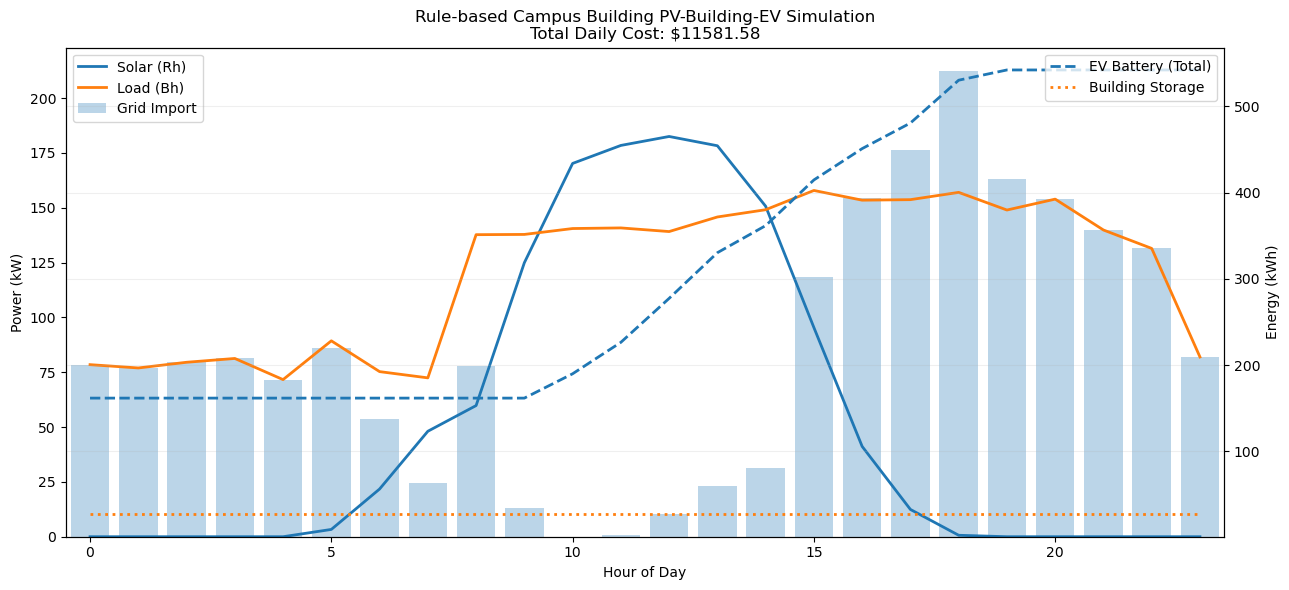

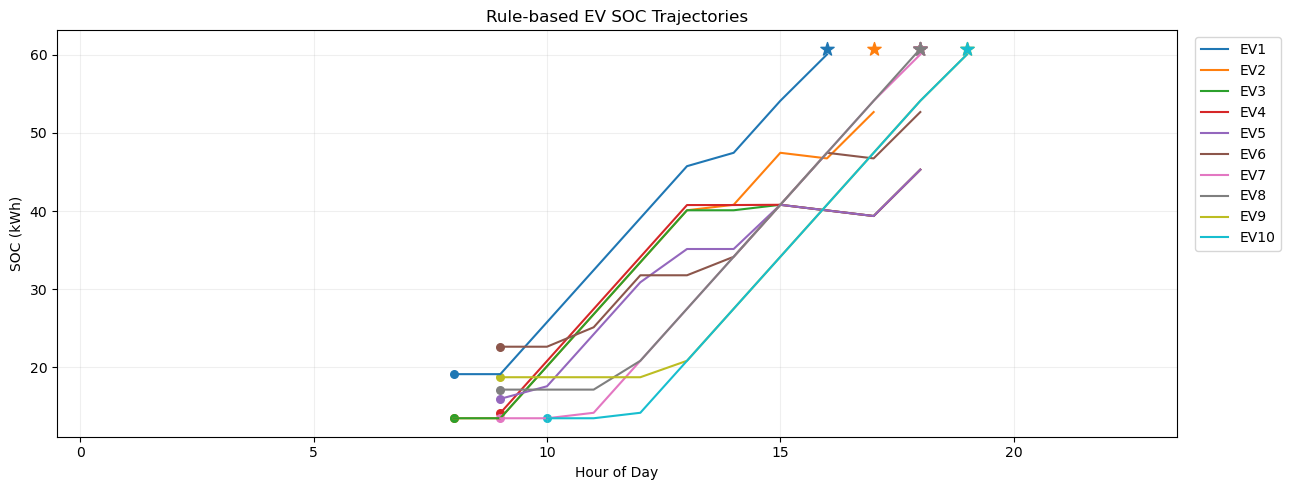

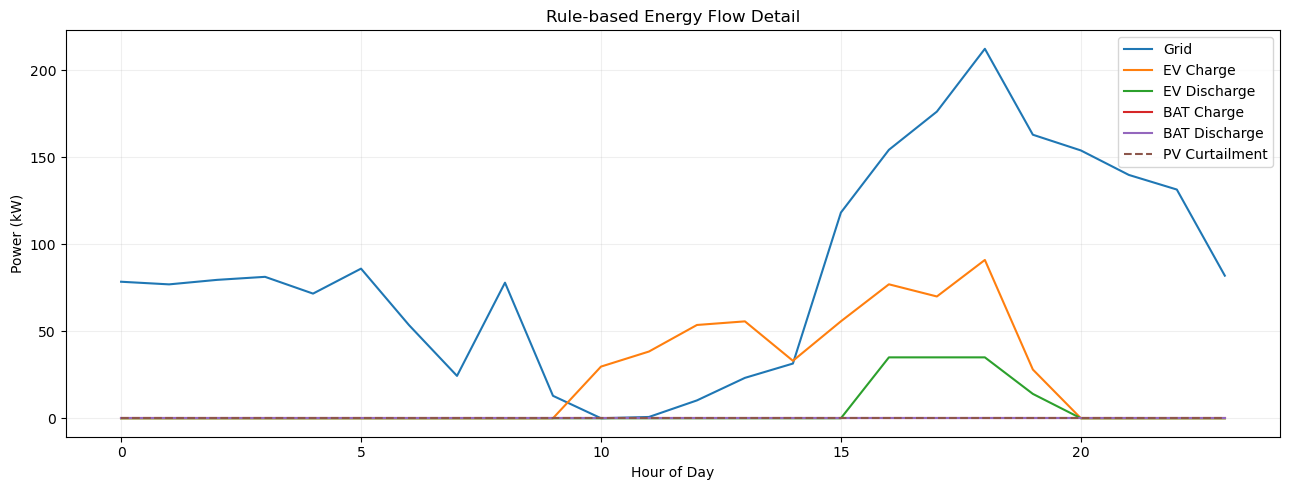

In [20]:
# ============================================================
# 8. Rule-based Simulation Cell
# ============================================================

# ---------- 基本檢查 ----------
assert len(rh) >= 24
assert len(bh) >= 24
assert len(price) >= 24

rh_sim = np.array(rh[:24], dtype=float)
bh_sim = np.array(bh[:24], dtype=float)
price_sim = np.array(price[:24], dtype=float)

# ---------- Rule-based 狀態初始化 ----------
ev_energy = np.array(soc_init_pcts, dtype=float) * ev_capacity_single
soc_ev_total = ev_energy.sum()

bat_energy = bat_init_pct * bat_cap
bat_min_energy = bat_min_pct * bat_cap
bat_max_energy = bat_max_pct * bat_cap

ev_min_pct = 0.2
ev_min_energy_each = ev_min_pct * ev_capacity_single

ev_target_energy = np.array(soc_target_pcts, dtype=float) * ev_capacity_single

results_sim = []

total_grid_cost_sim = 0
total_ev_deg_cost_sim = 0
total_bat_deg_cost_sim = 0
total_cost_sim = 0

print("\n===== Rule-based Simulation Using Same Inputs =====")
print(f"{'Hour':<5} | {'Available EVs':<14} | {'Grid':>8} | {'EV_CH':>8} | {'EV_DIS':>8} | {'BAT_CH':>8} | {'BAT_DIS':>8} | {'BAT_SOC':>8}")
print("-" * 95)

# ============================================================
# Rule-based Simulation
# ============================================================

for t in T:
    Rh = rh_sim[t]
    Bh = bh_sim[t]
    p = price_sim[t]

    grid_import = 0.0
    ev_charge_total = 0.0
    ev_dis_total = 0.0
    bat_charge = 0.0
    bat_dis = 0.0
    pv_curt = 0.0

    ev_charge_from_pv = 0.0
    ev_charge_from_grid = 0.0
    proactive_grid_ev_charge = 0.0
    last_minute_grid_ev_charge = 0.0
    must_charge_now_total = 0.0

    available_evs = [
        i for i in I
        if arrival_times[i] <= t < departure_times[i]
    ]

    # ========================================================
    # Step A. PV / Load balance
    # ========================================================

    if Rh >= Bh:
        surplus = Rh - Bh

        # 1. PV 優先充 EV
        if available_evs:
            station_remaining_ch = ev_station_ch_limit

            for i in available_evs:
                ev_room_input = max(0, (ev_capacity_single - ev_energy[i]) / eta_ch)
                ch_i = min(
                    surplus,
                    ev_ch_max_single,
                    station_remaining_ch,
                    ev_room_input
                )

                if ch_i > 0:
                    ev_energy[i] += ch_i * eta_ch
                    surplus -= ch_i
                    station_remaining_ch -= ch_i
                    ev_charge_total += ch_i
                    ev_charge_from_pv += ch_i

        # 2. PV 再充建築電池
        bat_room_input = max(0, (bat_max_energy - bat_energy) / eta_ch)
        bat_charge = min(
            surplus,
            bat_ch_max,
            bat_room_input
        )

        if bat_charge > 0:
            bat_energy += bat_charge * eta_ch
            surplus -= bat_charge

        # 3. 剩餘棄光
        pv_curt = max(0, surplus)

    else:
        deficit = Bh - Rh

        # 尖峰：建築電池 → EV → grid
        if 16 <= t <= 22:
            bat_dis_available = min(
                bat_dis_max,
                max(0, (bat_energy - bat_min_energy) * eta_dis)
            )

            bat_dis = min(deficit, bat_dis_available)

            if bat_dis > 0:
                bat_energy -= bat_dis / eta_dis
                deficit -= bat_dis

            if available_evs:
                station_remaining_dis = ev_station_dis_limit

                for i in available_evs:
                    ev_dis_available_i = min(
                        ev_dis_max_single,
                        station_remaining_dis,
                        max(0, (ev_energy[i] - ev_min_energy_each) * eta_dis)
                    )

                    dis_i = min(deficit, ev_dis_available_i)

                    if dis_i > 0:
                        ev_energy[i] -= dis_i / eta_dis
                        deficit -= dis_i
                        station_remaining_dis -= dis_i
                        ev_dis_total += dis_i

            grid_import = max(0, deficit)

        # 非尖峰：只用建築電池削負載
        else:
            bat_dis_available = min(
                bat_dis_max,
                max(0, (bat_energy - bat_min_energy) * eta_dis)
            )

            bat_dis = min(deficit, bat_dis_available)

            if bat_dis > 0:
                bat_energy -= bat_dis / eta_dis
                deficit -= bat_dis

            grid_import = max(0, deficit)

    # ========================================================
    # Step B. 可行性回推：避免 EV 離場 SOC 不達標
    # ========================================================

    for i in available_evs:
        dep_i = departure_times[i]
        target_i = ev_target_energy[i]

        if t < dep_i:
            energy_needed = max(0, target_i - ev_energy[i])

            # 若跳過現在，未來剩下 t+1 ~ dep_i-1
            remaining_hours_after_now = max(0, dep_i - t - 1)
            future_max_charge_if_skip_now = remaining_hours_after_now * ev_ch_max_single * eta_ch

            must_charge_now = max(0, energy_needed - future_max_charge_if_skip_now)
            must_charge_now_total += must_charge_now

            if must_charge_now > 0:
                charge_input_needed = must_charge_now / eta_ch

                current_ev_ch_used = 0  # rule-based 每台車這裡沒有逐台紀錄前面已用功率，保守處理
                feasible_grid_charge = min(
                    charge_input_needed,
                    ev_ch_max_single - current_ev_ch_used,
                    (ev_capacity_single - ev_energy[i]) / eta_ch
                )

                feasible_grid_charge = max(0, feasible_grid_charge)

                if feasible_grid_charge > 0:
                    ev_energy[i] += feasible_grid_charge * eta_ch
                    grid_import += feasible_grid_charge
                    ev_charge_total += feasible_grid_charge
                    ev_charge_from_grid += feasible_grid_charge
                    proactive_grid_ev_charge += feasible_grid_charge

    # ========================================================
    # Step C. 離場前最後補救
    # ========================================================

    for i in I:
        if departure_times[i] == t + 1:
            target_i = ev_target_energy[i]

            required_energy = max(0, target_i - ev_energy[i])

            if required_energy > 0:
                feasible_last_charge = min(
                    required_energy / eta_ch,
                    ev_ch_max_single,
                    (ev_capacity_single - ev_energy[i]) / eta_ch
                )

                feasible_last_charge = max(0, feasible_last_charge)

                if feasible_last_charge > 0:
                    ev_energy[i] += feasible_last_charge * eta_ch
                    grid_import += feasible_last_charge
                    ev_charge_total += feasible_last_charge
                    ev_charge_from_grid += feasible_last_charge
                    last_minute_grid_ev_charge += feasible_last_charge

    # ========================================================
    # Step D. SOC clamp
    # ========================================================

    ev_energy = np.clip(ev_energy, ev_min_energy_each, ev_capacity_single)
    bat_energy = min(max(bat_energy, bat_min_energy), bat_max_energy)

    # ========================================================
    # Step E. Cost
    # ========================================================

    ev_deg_cost_sim = ev_dis_total * ev_deg_cost
    bat_deg_cost_sim = bat_dis * bat_deg_cost
    grid_cost_sim = grid_import * p

    total_grid_cost_sim += grid_cost_sim
    total_ev_deg_cost_sim += ev_deg_cost_sim
    total_bat_deg_cost_sim += bat_deg_cost_sim
    total_cost_sim += grid_cost_sim + ev_deg_cost_sim + bat_deg_cost_sim

    row = {
        "Hour": t,
        "Rh": Rh,
        "Bh": Bh,
        "Price": p,
        "Grid": grid_import,
        "Grid_Cost": grid_cost_sim,

        "EV_Charge_Total": ev_charge_total,
        "EV_Charge_from_PV": ev_charge_from_pv,
        "EV_Charge_from_Grid": ev_charge_from_grid,
        "EV_Charge_Proactive_Grid": proactive_grid_ev_charge,
        "EV_Charge_LastMinute_Grid": last_minute_grid_ev_charge,
        "Must_Charge_Now": must_charge_now_total,

        "EV_Discharge_Total": ev_dis_total,
        "EV_Deg_Cost": ev_deg_cost_sim,

        "BAT_Charge": bat_charge,
        "BAT_Discharge": bat_dis,
        "BAT_Deg_Cost": bat_deg_cost_sim,

        "BAT_SOC": bat_energy,
        "EV_SOC_Total": ev_energy.sum(),
        "PV_Curt": pv_curt,
        "Available_EVs": len(available_evs),
    }

    for i in I:
        row[f"EV{i+1}_SOC"] = ev_energy[i]

    results_sim.append(row)

    print(
        f"{t:02d}:00 | {len(available_evs):<14} | "
        f"{grid_import:>8.2f} | {ev_charge_total:>8.2f} | {ev_dis_total:>8.2f} | "
        f"{bat_charge:>8.2f} | {bat_dis:>8.2f} | {bat_energy:>8.2f}"
    )

df_rule = pd.DataFrame(results_sim)

# ============================================================
# Summary
# ============================================================

print("\n===== Rule-based Simulation Summary =====")
print(f"Total daily cost: ${total_cost_sim:.2f}")
print(f"Total grid import: {df_rule['Grid'].sum():.2f} kWh")
print(f"Total PV curtailment: {df_rule['PV_Curt'].sum():.2f} kWh")
print(f"Total EV charge: {df_rule['EV_Charge_Total'].sum():.2f} kWh")
print(f"Total EV discharge: {df_rule['EV_Discharge_Total'].sum():.2f} kWh")

print("\n===== Departure SOC Check =====")
for i in I:
    dep_t = departure_times[i]
    target = ev_target_energy[i]

    if dep_t <= 24:
        dep_soc = ev_energy[i] if dep_t == 24 else df_rule.loc[df_rule["Hour"] == dep_t - 1, f"EV{i+1}_SOC"].values[0]
        print(f"EV{i+1:2d} | Arrive {arrival_times[i]:02d}:00 | Depart {dep_t:02d}:00 | SOC/Target: {dep_soc:.2f} / {target:.2f} kWh")

# ============================================================
# Plot 1: Energy Flow
# ============================================================

fig, ax1 = plt.subplots(figsize=(13, 6))

ax1.plot(df_rule["Hour"], df_rule["Rh"], label="Solar (Rh)", linewidth=2)
ax1.plot(df_rule["Hour"], df_rule["Bh"], label="Load (Bh)", linewidth=2)
ax1.bar(df_rule["Hour"], df_rule["Grid"], label="Grid Import", alpha=0.3)

ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Power (kW)")
ax1.set_xlim(-0.5, 23.5)

ax2 = ax1.twinx()
ax2.plot(df_rule["Hour"], df_rule["EV_SOC_Total"], label="EV Battery (Total)", linestyle="--", linewidth=2)
ax2.plot(df_rule["Hour"], df_rule["BAT_SOC"], label="Building Storage", linestyle=":", linewidth=2)
ax2.set_ylabel("Energy (kWh)")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1, labels_1, loc="upper left")
ax2.legend(lines_2, labels_2, loc="upper right")

plt.title(f"Rule-based Campus Building PV-Building-EV Simulation\nTotal Daily Cost: ${total_cost_sim:.2f}")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 2: EV SOC
# ============================================================

plt.figure(figsize=(13, 5))

for i in I:
    arr_t = arrival_times[i]
    dep_t = departure_times[i]

    plot_start = max(0, arr_t)
    plot_end = min(23, dep_t - 1)

    if plot_start <= plot_end:
        time_range = range(plot_start, plot_end + 1)
        soc_values = [df_rule.loc[df_rule["Hour"] == tt, f"EV{i+1}_SOC"].values[0] for tt in time_range]

        line, = plt.plot(time_range, soc_values, label=f"EV{i+1}")
        plt.scatter(arr_t, soc_values[0], color=line.get_color(), marker="o", s=30)
        plt.scatter(plot_end, soc_target_pcts[i] * ev_capacity_single, color=line.get_color(), marker="*", s=100)

plt.xlabel("Hour of Day")
plt.ylabel("SOC (kWh)")
plt.title("Rule-based EV SOC Trajectories")
plt.xlim(-0.5, 23.5)
plt.grid(True, alpha=0.2)
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ============================================================
# Plot 3: Dispatch Detail
# ============================================================

plt.figure(figsize=(13, 5))

plt.plot(df_rule["Hour"], df_rule["Grid"], label="Grid")
plt.plot(df_rule["Hour"], df_rule["EV_Charge_Total"], label="EV Charge")
plt.plot(df_rule["Hour"], df_rule["EV_Discharge_Total"], label="EV Discharge")
plt.plot(df_rule["Hour"], df_rule["BAT_Charge"], label="BAT Charge")
plt.plot(df_rule["Hour"], df_rule["BAT_Discharge"], label="BAT Discharge")
plt.plot(df_rule["Hour"], df_rule["PV_Curt"], label="PV Curtailment", linestyle="--")

plt.xlabel("Hour of Day")
plt.ylabel("Power (kW)")
plt.title("Rule-based Energy Flow Detail")
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df_weather = pd.read_csv("466920-2026-05-12.csv", header=0)
df_weather = df_weather.drop(0).reset_index(drop=True)

# 氣溫 (T_amb) 與 日照量 (GloblRad)
t_amb_data = pd.to_numeric(df_weather['氣溫(℃)'], errors='coerce').ffill().values
rad_mj_data = pd.to_numeric(df_weather['全天空日射量(MJ/㎡)'], errors='coerce').fillna(0).values

# 單位轉換：1 MJ/m^2/hour = 1/3.6 kW/m^2
rad_kw_data = rad_mj_data / 3.6

# PV 面板物理參數設定
T_ref = 25.0              
K_pv = -3.7e-3            
A_pv = 1081.65            
eta_pv = 0.22            # https://netzero.sinica.edu.tw/cases_detail/12

rh = np.zeros(24)
for t in range(24):
    if rad_kw_data[t] > 0:
        # 面板升溫公式 (Eq. 3.2)，帶入的 Rad 轉換為 W/m^2
        Rad_W = rad_kw_data[t] * 1000
        T_pv = t_amb_data[t] + 0.0256 * Rad_W
        
        # 實際發電功率公式 (Eq. 3.1)，輸出為 kW
        p_pv_t = rad_kw_data[t] * A_pv * (1 + K_pv * (T_pv - T_ref)) * eta_pv
        rh[t] = max(0, p_pv_t)
    else:
        rh[t] = 0

print(rh)


[  0.           0.           0.           0.           0.
   3.32392814  21.75301219  48.08892707  59.81033563 124.95132273
 170.22867759 178.436624   182.51956363 178.2903693  150.702112
  95.37912795  41.16954031  12.43596415   0.6601007    0.
   0.           0.           0.           0.        ]


In [ ]:
[ 0.          0.          0.          0.          0.          1.32523416
  8.57961333 19.66638603 28.67233168 40.78375278 39.48041063 49.08337885
 49.12055396 13.20929675 19.10808753 19.79111831 10.60987355  2.66766453
  0.66768246  0.          0.          0.          0.          0.        ]

[  0.           0.           0.           0.           0.
   3.32392814  21.75301219  48.08892707  59.81033563 124.95132273
 170.22867759 178.436624   182.51956363 178.2903693  150.702112
  95.37912795  41.16954031  12.43596415   0.6601007    0.
   0.           0.           0.           0.        ]